### Lasso Regression

Lasso Regression is like Ridge's aggressive cousin. Instead of just shrinking coefficients (Ridge), Lasso uses an L1 penalty that can completely eliminate unimportant features by shrinking their coefficients to exactly zero. This makes it great for feature selection—it tells you which features actually matter. The α parameter controls the strength: larger α = more features get eliminated. If you have 100 features but only 10 matter, Lasso will find them for you!



In [ ]:
"""STANDARD LINEAR REGRESSION:
Loss = Σ(yᵢ - ŷᵢ)²
      ╔═══════════════════════╗
      ║  No penalty → ALL     ║
      ║  coefficients survive ║
      ╚═══════════════════════╝

RIDGE (L2 Penalty):
Loss = Σ(yᵢ - ŷᵢ)² + α·Σ(wⱼ²)
      ╔═══════════════════════╗
      ║  Shrinks coefficients ║
      ║  but NEVER to zero    ║
      ╚═══════════════════════╝

LASSO (L1 Penalty):
Loss = Σ(yᵢ - ŷᵢ)² + α·Σ|wⱼ|
      ╔═══════════════════════╗
      ║  Can make coefficients║
      ║  EXACTLY ZERO! 🎯     ║
      ╚═══════════════════════╝"""

LASSO REGRESSION - FEATURE SELECTION IN ACTION

📊 LINEAR REGRESSION (Yesterday's Model)
--------------------------------------------------
MSE: 2900.1936
R² Score: 0.4526

Coefficients:
  age:   1.7538
  sex: -11.5118
  bmi:  25.6071
  bp:  16.8289
  s1: -44.4489
  s2:  24.6410
  s3:   7.6770
  s4:  13.1388
  s5:  35.1612
  s6:   2.3514

🏔️ RIDGE REGRESSION (α=1.0)
--------------------------------------------------
MSE: 2892.0146
R² Score: 0.4541

Coefficients (shrunk but not zero):
  age:   1.8073
  sex: -11.4482
  bmi:  25.7327
  bp:  16.7343
  s1: -34.6720
  s2:  17.0531
  s3:   3.3699
  s4:  11.7643
  s5:  31.3784
  s6:   2.4581

🎯 LASSO REGRESSION - WATCHING FEATURES DIE!

α = 0.001
  MSE: 2900.0084
  R² Score: 0.4526
  Features kept: 10/10
  Features eliminated: 0/10
  Coefficients:
    ✅ age:   1.7535
    ✅ sex: -11.5099
    ✅ bmi:  25.6093
    ✅ bp:  16.8270
    ✅ s1: -44.2978
    ✅ s2:  24.5272
    ✅ s3:   7.6056
    ✅ s4:  13.1097
    ✅ s5:  35.1058
    ✅ s6:   2.3518

α = 0.

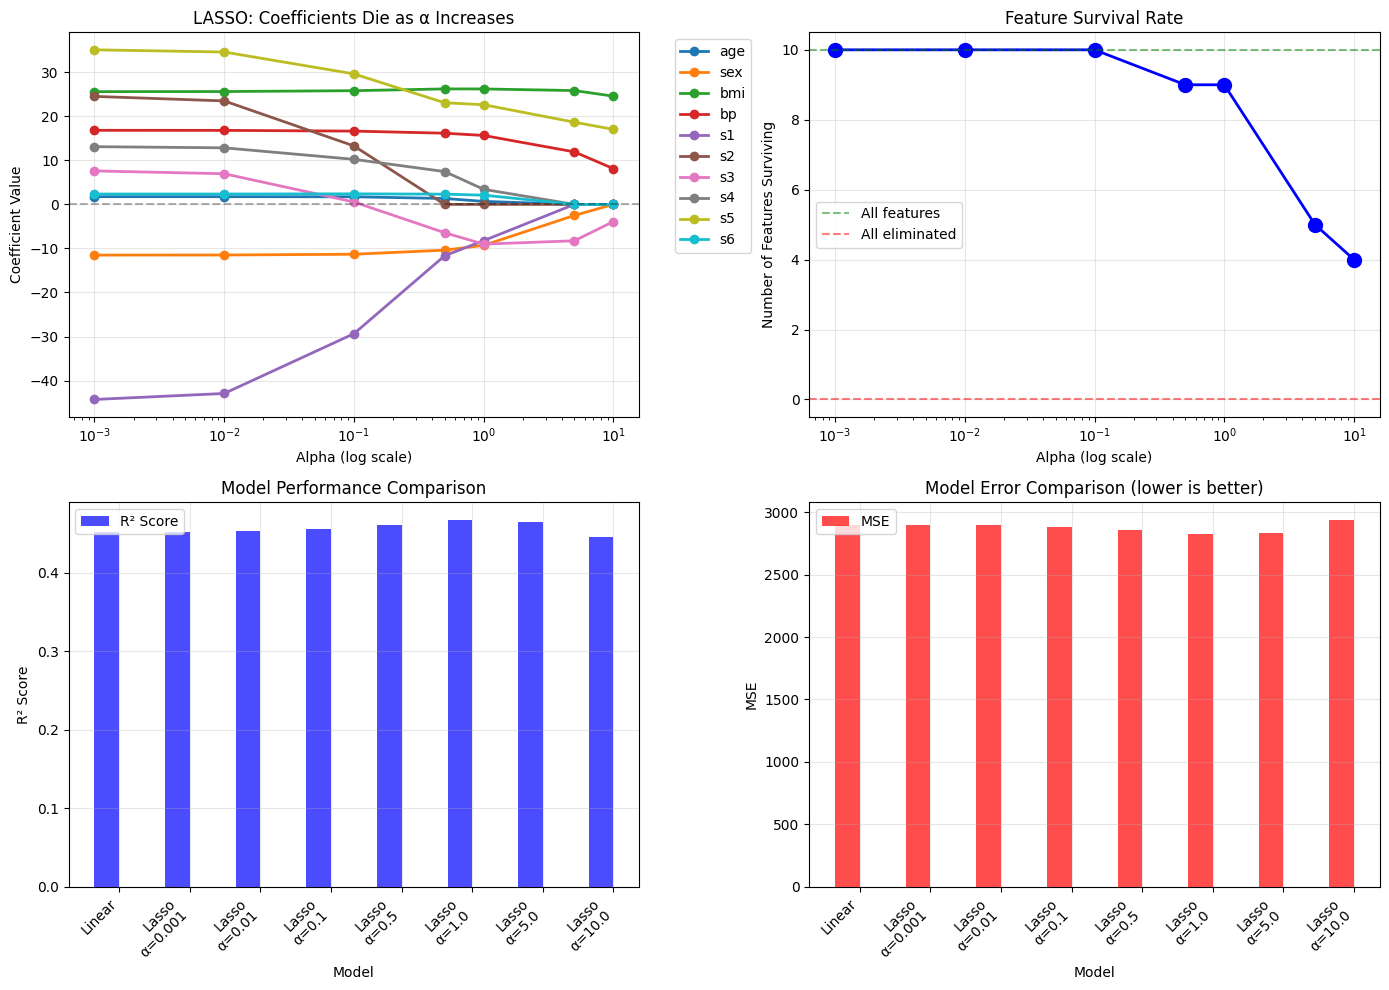


📋 FEATURE SELECTION SUMMARY

✅ BEST LASSO MODEL (α=1.0)

Features selected by Lasso (α=1.0):
  ✅ age: 0.6870
  ✅ sex: -9.2975
  ✅ bmi: 26.2192
  ✅ bp: 15.6573
  ✅ s1: -8.2282
  ❌ s2: -0.0000 (ELIMINATED!)
  ✅ s3: -9.0241
  ✅ s4: 3.4209
  ✅ s5: 22.6365
  ✅ s6: 2.0986

🏆 FINAL MODEL COMPARISON
        Model  R² Score         MSE  Features Used
       Linear  0.452603 2900.193628             10
Ridge (α=1.0)  0.454147 2892.014566             10
Lasso (α=1.0)  0.466877 2824.568094              9

✅ LASSO outperformed Ridge!

💡 KEY INSIGHT: Lasso eliminated 1 features (out of 10) making the model simpler!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load dataset
data = load_diabetes()
X, y = data.data, data.target
feature_names = data.feature_names

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (CRITICAL for Lasso!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("="*70)
print("LASSO REGRESSION - FEATURE SELECTION IN ACTION")
print("="*70)

# 1. Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("\nLINEAR REGRESSION (Yesterday's Model)")
print("-"*50)
print(f"MSE: {lr_mse:.4f}")
print(f"R² Score: {lr_r2:.4f}")
print("\nCoefficients:")
for name, coef in zip(feature_names, lr.coef_):
    print(f"  {name}: {coef:>8.4f}")

# 2. Ridge Regression (yesterday's champion)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("\nRIDGE REGRESSION (α=1.0)")
print("-"*50)
print(f"MSE: {ridge_mse:.4f}")
print(f"R² Score: {ridge_r2:.4f}")
print("\nCoefficients (shrunk but not zero):")
for name, coef in zip(feature_names, ridge.coef_):
    print(f"  {name}: {coef:>8.4f}")

# 3. Lasso Regression with different alpha values
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
lasso_results = {}

print("\n" + "="*70)
print("LASSO REGRESSION - WATCHING FEATURES DIE!")
print("="*70)

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Count how many features survive (non-zero coefficients)
    non_zero = np.sum(np.abs(lasso.coef_) > 1e-6)
    zero_count = len(feature_names) - non_zero
    
    lasso_results[alpha] = {
        'model': lasso,
        'mse': mse,
        'r2': r2,
        'coef': lasso.coef_,
        'non_zero': non_zero,
        'zero_count': zero_count
    }
    
    print(f"\nα = {alpha}")
    print(f"  MSE: {mse:.4f}")
    print(f"  R² Score: {r2:.4f}")
    print(f"  Features kept: {non_zero}/{len(feature_names)}")
    print(f"  Features eliminated: {zero_count}/{len(feature_names)}")
    print("  Coefficients:")
    for name, coef in zip(feature_names, lasso.coef_):
        status = "💀" if abs(coef) < 1e-6 else "✅"
        print(f"    {status} {name}: {coef:>8.4f}")

# 4. Visual Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Coefficient paths
ax1 = axes[0, 0]
for i, feature in enumerate(feature_names):
    coefs = [lasso_results[alpha]['coef'][i] for alpha in alphas]
    ax1.plot(alphas, coefs, marker='o', label=feature, linewidth=2)
ax1.set_xscale('log')
ax1.set_xlabel('Alpha (log scale)')
ax1.set_ylabel('Coefficient Value')
ax1.set_title('LASSO: Coefficients Die as α Increases')
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Feature survival
ax2 = axes[0, 1]
survival = [lasso_results[alpha]['non_zero'] for alpha in alphas]
ax2.plot(alphas, survival, 'bo-', linewidth=2, markersize=10)
ax2.set_xscale('log')
ax2.set_xlabel('Alpha (log scale)')
ax2.set_ylabel('Number of Features Surviving')
ax2.set_title('Feature Survival Rate')
ax2.axhline(y=len(feature_names), color='green', linestyle='--', alpha=0.5, label='All features')
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='All eliminated')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Performance comparison
ax3 = axes[1, 0]
alphas_labels = ['Linear'] + [f'Lasso\nα={a}' for a in alphas]
r2_scores = [lr_r2] + [lasso_results[alpha]['r2'] for alpha in alphas]
mse_scores = [lr_mse] + [lasso_results[alpha]['mse'] for alpha in alphas]

x = np.arange(len(alphas_labels))
width = 0.35
bars1 = ax3.bar(x - width/2, r2_scores, width, label='R² Score', color='blue', alpha=0.7)
ax3.set_xlabel('Model')
ax3.set_ylabel('R² Score')
ax3.set_title('Model Performance Comparison')
ax3.set_xticks(x)
ax3.set_xticklabels(alphas_labels, rotation=45, ha='right')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

# Plot 4: MSE comparison
ax4 = axes[1, 1]
bars2 = ax4.bar(x - width/2, mse_scores, width, label='MSE', color='red', alpha=0.7)
ax4.set_xlabel('Model')
ax4.set_ylabel('MSE')
ax4.set_title('Model Error Comparison (lower is better)')
ax4.set_xticks(x)
ax4.set_xticklabels(alphas_labels, rotation=45, ha='right')
ax4.legend(loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Feature Selection Summary
print("\n" + "="*70)
print(" FEATURE SELECTION SUMMARY")
print("="*70)

print(f"\n BEST LASSO MODEL (α={alphas[np.argmin([lasso_results[a]['mse'] for a in alphas])]})")
best_alpha = alphas[np.argmin([lasso_results[a]['mse'] for a in alphas])]
best_lasso = lasso_results[best_alpha]

print(f"\nFeatures selected by Lasso (α={best_alpha}):")
for name, coef in zip(feature_names, best_lasso['coef']):
    if abs(coef) > 1e-6:
        print(f" {name}: {coef:.4f}")
    else:
        print(f" {name}: {coef:.4f} (ELIMINATED!)")

# 6. Final Comparison Table
print("\n" + "="*70)
print(" FINAL MODEL COMPARISON")
print("="*70)

comparison_data = {
    'Model': ['Linear', 'Ridge (α=1.0)', f'Lasso (α={best_alpha})'],
    'R² Score': [lr_r2, ridge_r2, best_lasso['r2']],
    'MSE': [lr_mse, ridge_mse, best_lasso['mse']],
    'Features Used': [len(feature_names), len(feature_names), best_lasso['non_zero']]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

if best_lasso['r2'] > ridge_r2:
    print(f"\n LASSO outperformed Ridge!")
else:
    print(f"\n Ridge still better for this dataset")
    
print(f"\n KEY INSIGHT: Lasso eliminated {best_lasso['zero_count']} features "
      f"(out of {len(feature_names)}) making the model simpler!")